In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# DATA UNDERSTANDING AND CLEANING

In [9]:
df = pd.read_csv("backend/data/spotify_tracks.csv")

df = df.drop_duplicates(subset=['track_name', 'artist_name'])

df = df.dropna()

# FEATURE SELECTION

In [10]:
features = [
    'acousticness','danceability','energy','instrumentalness',
    'liveness','loudness','speechiness','tempo','valence'
]

X=df[features]

# EDA

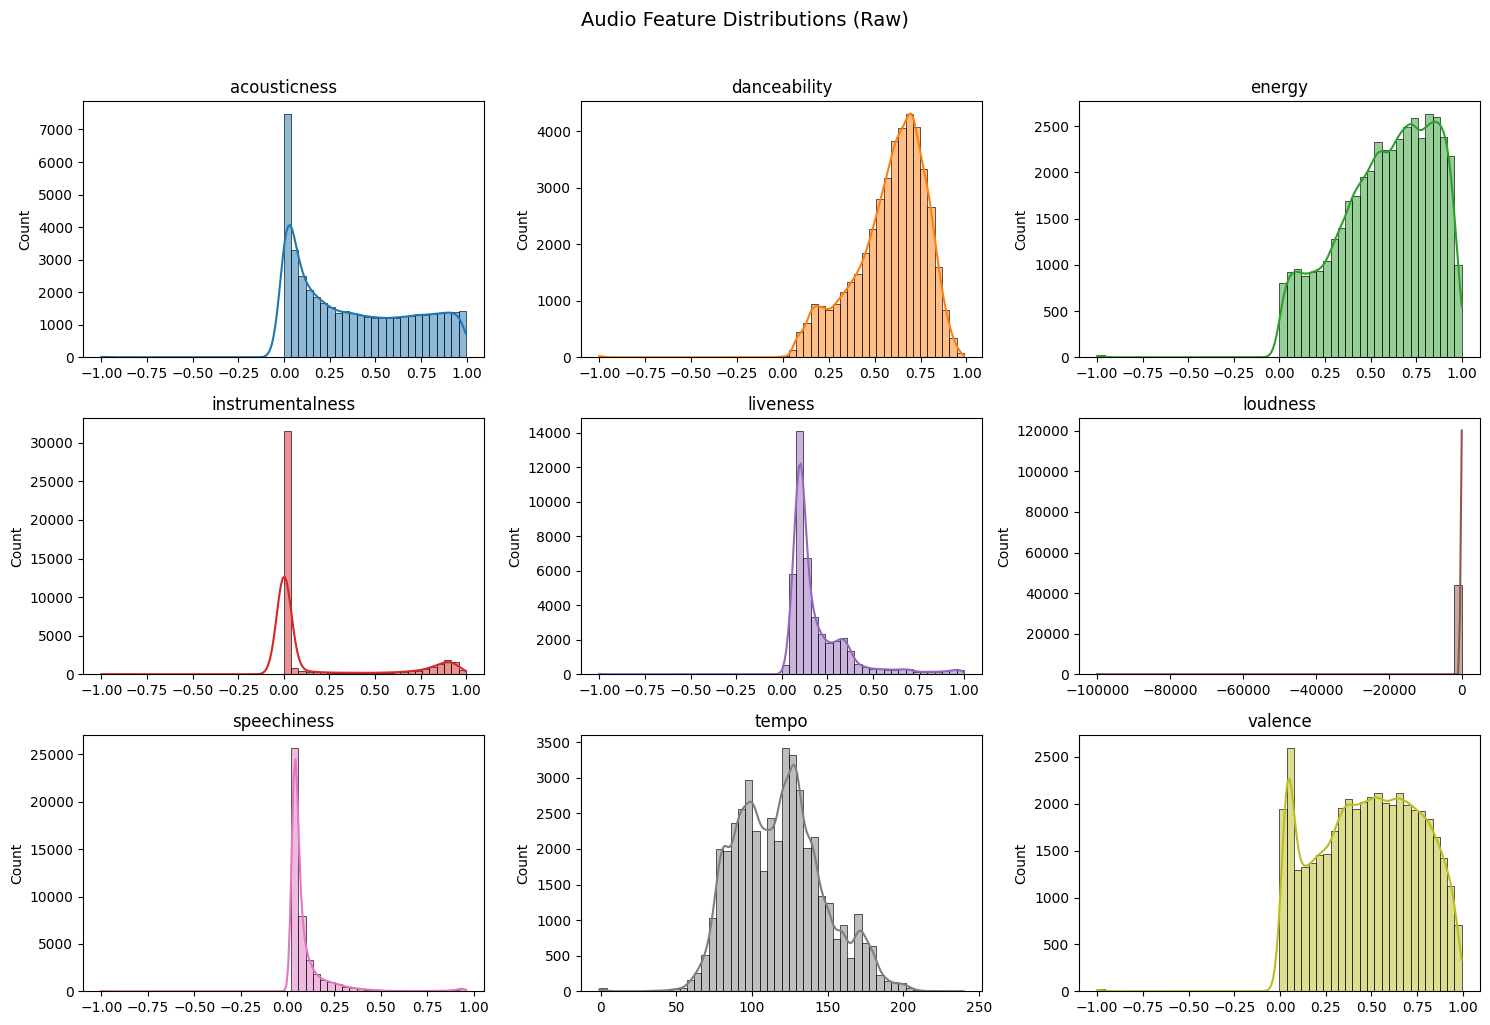

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, feat, color in zip(
    axes.flatten(),
    features,
    sns.color_palette("tab10", len(features))
):
    sns.histplot(df[feat], bins=50, kde=True, ax=ax, color=color)
    ax.set_title(feat)
    ax.set_xlabel("")

plt.suptitle("Audio Feature Distributions (Raw)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# STANDARD SCALER

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# CLUSTERING USING KMEANS

In [13]:
kmeans = KMeans(n_clusters=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

y = df['cluster']

# SPLITTING DATASET

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# MODEL TRAINING

### 1. LOGISTIC REGRESSION

Logistic Regression Accuracy: 0.9896590909090909

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1955
           1       0.99      0.99      0.99      1121
           2       1.00      1.00      1.00         6
           3       0.99      0.98      0.99      1376
           4       0.99      0.99      0.99       991
           5       0.98      0.99      0.98       462
           6       0.99      0.99      0.99      1503
           7       0.98      0.99      0.99       552
           8       0.98      0.98      0.98       705
           9       1.00      0.99      1.00       129

    accuracy                           0.99      8800
   macro avg       0.99      0.99      0.99      8800
weighted avg       0.99      0.99      0.99      8800



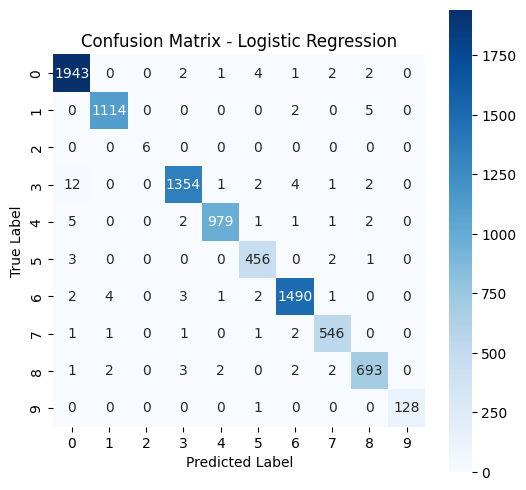

In [15]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

preds = model_lr.predict(X_test)

acc = accuracy_score(y_test, preds)
print("Logistic Regression Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 2. RANDOM FOREST

Random Forest Accuracy: 0.9577272727272728

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1955
           1       0.97      0.98      0.98      1121
           2       1.00      1.00      1.00         6
           3       0.95      0.96      0.95      1376
           4       0.96      0.93      0.94       991
           5       0.95      0.92      0.93       462
           6       0.96      0.96      0.96      1503
           7       0.97      0.96      0.96       552
           8       0.94      0.95      0.95       705
           9       1.00      0.99      1.00       129

    accuracy                           0.96      8800
   macro avg       0.97      0.96      0.96      8800
weighted avg       0.96      0.96      0.96      8800



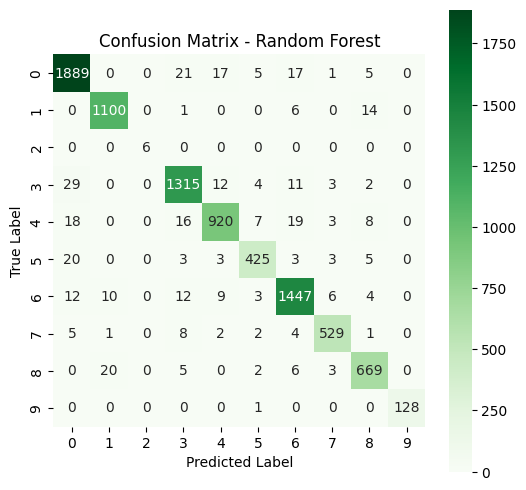

In [16]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()

model_rf.fit(X_train, y_train)

preds = model_rf.predict(X_test)

acc = accuracy_score(y_test, preds)
print("Random Forest Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    square=True,
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 3. KNN 

KNN Accuracy: 0.9328409090909091

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      1955
           1       0.97      0.98      0.97      1121
           2       1.00      1.00      1.00         6
           3       0.92      0.92      0.92      1376
           4       0.93      0.89      0.91       991
           5       0.92      0.86      0.89       462
           6       0.93      0.94      0.93      1503
           7       0.97      0.93      0.95       552
           8       0.94      0.93      0.94       705
           9       1.00      0.98      0.99       129

    accuracy                           0.93      8800
   macro avg       0.95      0.94      0.94      8800
weighted avg       0.93      0.93      0.93      8800



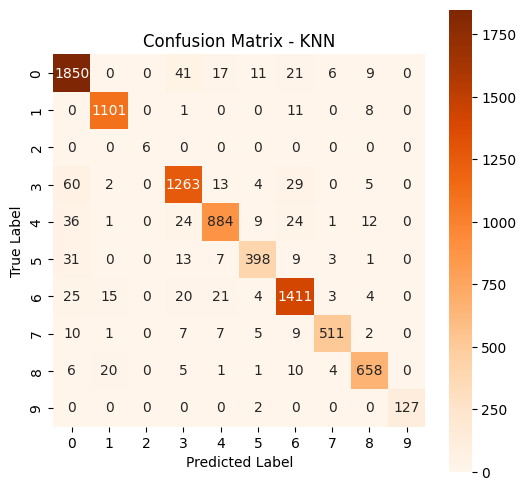

In [17]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier()

model_knn.fit(X_train, y_train)

preds = model_knn.predict(X_test)

acc = accuracy_score(y_test, preds)
print("KNN Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    square=True,
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - KNN")
plt.show()

## 4. DECISION TREE

Decision Tree Accuracy: 0.9261363636363636

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1955
           1       0.95      0.94      0.95      1121
           2       1.00      1.00      1.00         6
           3       0.93      0.93      0.93      1376
           4       0.91      0.89      0.90       991
           5       0.89      0.86      0.88       462
           6       0.93      0.93      0.93      1503
           7       0.95      0.93      0.94       552
           8       0.91      0.91      0.91       705
           9       0.97      0.95      0.96       129

    accuracy                           0.93      8800
   macro avg       0.94      0.93      0.93      8800
weighted avg       0.93      0.93      0.93      8800



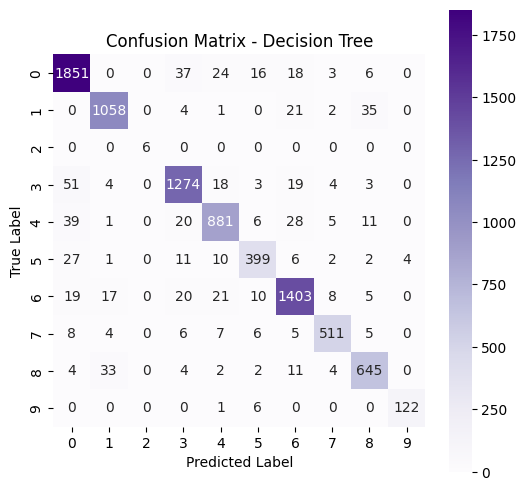

In [18]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier()

model_dt.fit(X_train, y_train)

preds = model_dt.predict(X_test)

acc = accuracy_score(y_test, preds)
print("Decision Tree Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    square=True,
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## 4. SVM

SVM Accuracy: 0.9845454545454545

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1955
           1       0.99      1.00      1.00      1121
           2       1.00      1.00      1.00         6
           3       0.98      0.98      0.98      1376
           4       0.99      0.97      0.98       991
           5       0.97      0.97      0.97       462
           6       0.98      0.99      0.98      1503
           7       0.98      0.99      0.98       552
           8       0.98      0.98      0.98       705
           9       1.00      0.98      0.99       129

    accuracy                           0.98      8800
   macro avg       0.99      0.98      0.99      8800
weighted avg       0.98      0.98      0.98      8800



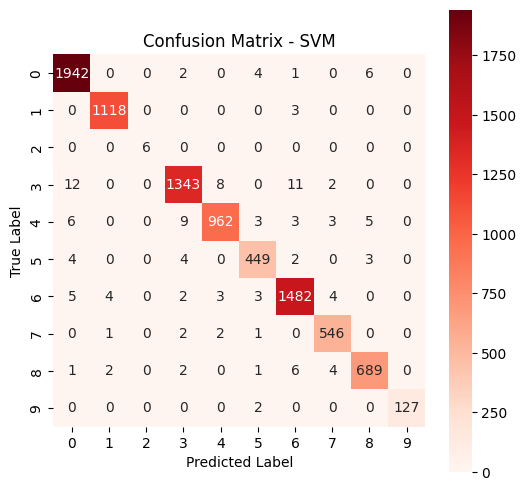

In [19]:
from sklearn.svm import SVC

model_svm = SVC()

model_svm.fit(X_train, y_train)

preds = model_svm.predict(X_test)

acc = accuracy_score(y_test, preds)
print("SVM Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    square=True,
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM")
plt.show()

# MODEL COMPARISON

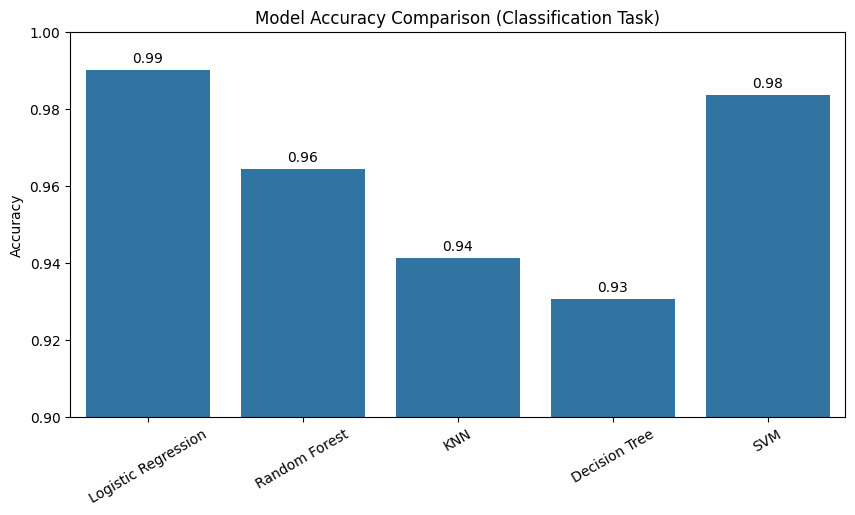


FINAL CONCLUSION

Although multiple machine learning models such as Logistic Regression,
Random Forest, KNN, Decision Tree, and SVM achieved very high accuracy
(above 93%), they are not suitable for building a recommendation system.

Reason:

1. These models are classification-based and rely on predefined labels (clusters).
2. They group songs into fixed clusters rather than finding truly similar songs.
3. Songs within the same cluster are not necessarily closely related.
4. This results in less precise and sometimes irrelevant recommendations.

In contrast, Cosine Similarity:

✔ Directly compares songs using feature vectors  
✔ Finds the most similar songs (pairwise comparison)  
✔ Provides more accurate and personalized recommendations  

Therefore, Cosine Similarity is chosen as the final approach
for building the music recommendation system.



In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Model accuracy results (use your actual values if different)
results = {
    "Logistic Regression": 0.9901,
    "Random Forest": 0.9642,
    "KNN": 0.9411,
    "Decision Tree": 0.9306,
    "SVM": 0.9836
}

# Plot accuracy comparison
plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))

plt.title("Model Accuracy Comparison (Classification Task)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

for i, v in enumerate(results.values()):
    plt.text(i, v + 0.002, f"{v:.2f}", ha='center')

plt.ylim(0.90, 1.00)
plt.show()


# Final Conclusion Print
print("\n" + "="*60)
print("FINAL CONCLUSION")
print("="*60)

print("""
Although multiple machine learning models such as Logistic Regression,
Random Forest, KNN, Decision Tree, and SVM achieved very high accuracy
(above 93%), they are not suitable for building a recommendation system.

Reason:

1. These models are classification-based and rely on predefined labels (clusters).
2. They group songs into fixed clusters rather than finding truly similar songs.
3. Songs within the same cluster are not necessarily closely related.
4. This results in less precise and sometimes irrelevant recommendations.

In contrast, Cosine Similarity:

✔ Directly compares songs using feature vectors  
✔ Finds the most similar songs (pairwise comparison)  
✔ Provides more accurate and personalized recommendations  

Therefore, Cosine Similarity is chosen as the final approach
for building the music recommendation system.
""")

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [23]:
models = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "KNN": model_knn,
    "Decision Tree": model_dt,
    "SVM": model_svm
}

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metrics_data = []

for name, model in models.items():
    
    preds = model.predict(X_test)
    
    metrics_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average='weighted'),
        "Recall": recall_score(y_test, preds, average='weighted'),
        "F1 Score": f1_score(y_test, preds, average='weighted')
    })

df_metrics = pd.DataFrame(metrics_data)
df_metrics

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.989659,0.989680,0.989659,0.989661
1,Random Forest,0.957727,0.957704,0.957727,0.957673
2,KNN,0.932841,0.932954,0.932841,0.932706
3,Decision Tree,0.926136,0.926109,0.926136,0.926055
4,SVM,0.984545,0.984554,0.984545,0.984532


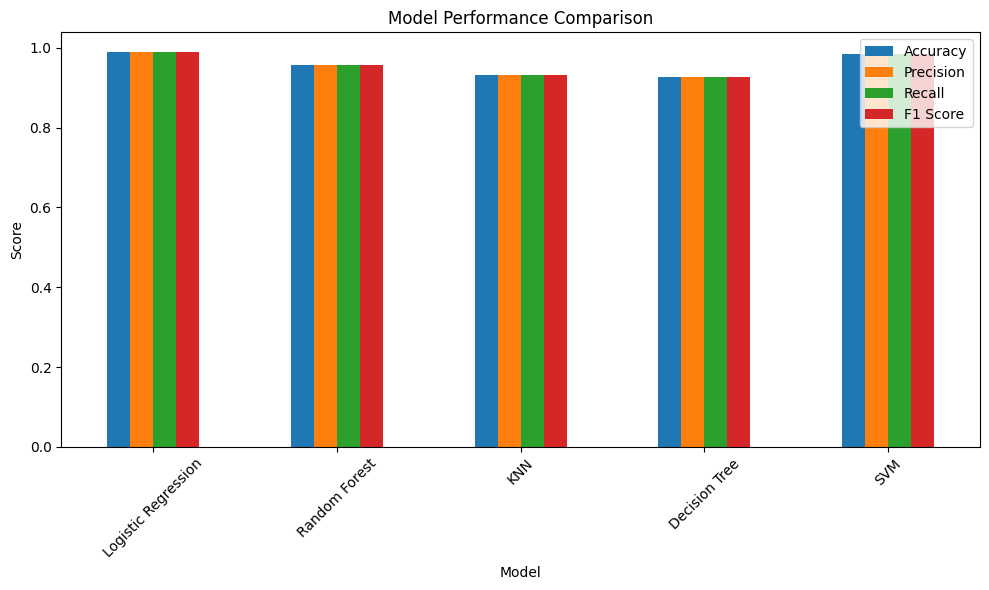

In [26]:
df_metrics.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()